# 📡 Telecom Customer Churn — Analysis & Prediction
---
**Dataset:** Telco Customer Churn (IBM Watson / Kaggle)  
**Download:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn

> Place `WA_Fn-UseC_-Telco-Customer-Churn.csv` in the **same folder** as this notebook, then run all cells top-to-bottom.

### Project Objectives
1. Prepare and clean the Telco Customer Churn dataset  
2. Perform exploratory analysis and customer segmentation  
3. Develop and evaluate **5 ML models**: Logistic Regression, Random Forest, Gradient Boosting, AdaBoost, KNN  
4. Apply **Explainable AI** (LIME + SHAP) to interpret predictions  
5. Generate churn probability scores and actionable retention recommendations  


## 📦 Cell 1 — Install Dependencies
Run once to install every required package.

In [1]:
import subprocess, sys

packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'scikit-learn', 'imbalanced-learn', 'lime', 'shap', 'plotly'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed.')


✅ All packages installed.


## 📚 Cell 2 — Import Libraries
Import every library used throughout the project.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Imbalanced learning
from imblearn.over_sampling import SMOTE

# Explainable AI
import lime
import lime.lime_tabular
import shap

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Global plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('✅ All libraries imported.')


✅ All libraries imported.


## 📂 Cell 3 — Load Dataset
Load the CSV with `encoding='utf-8-sig'` to strip any BOM characters, and `.str.strip()` to remove hidden whitespace from column names (fixes `KeyError: 'Churn'` and similar issues).

In [3]:
# encoding='utf-8-sig' removes BOM characters that corrupt column names
df = pd.read_csv(
    'WA_Fn-UseC_-Telco-Customer-Churn.xls',
    encoding='utf-8-sig'
)

# Strip whitespace from every column name
df.columns = df.columns.str.strip()

print(f'✅ Dataset loaded:  {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
print('Columns:', df.columns.tolist())


✅ Dataset loaded:  7,043 rows  ×  21 columns
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 🔍 Cell 4 — First Look: Head & Shape
Preview the first 5 rows and confirm the dataset dimensions.

In [4]:
print(f'Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
display(df.head())

Shape: 7,043 rows  ×  21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 🗂️ Cell 5 — Data Types & Column Overview
Inspect each column's dtype and count of unique values to distinguish categorical from numeric features.

In [5]:
print('--- Data Types ---')
print(df.dtypes)

print('\n--- Unique Values Per Column ---')
for col in df.columns:
    print(f'  {col:<30}  {df[col].nunique():>5} unique   dtype: {df[col].dtype}')


--- Data Types ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

--- Unique Values Per Column ---
  customerID                       7043 unique   dtype: object
  gender                              2 unique   dtype: object
  SeniorCitizen                       2 unique   dtype: int64
  Partner                             2 unique   dtype: object
  Dependents                          2 unique   dtype: object
  tenure                       

## 📊 Cell 6 — Descriptive Statistics
Summary statistics for numeric features and categorical features separately.

In [6]:
print('--- Numeric Features ---')
display(df.describe())

print('\n--- Categorical Features ---')
display(df.describe(include='object'))

--- Numeric Features ---


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



--- Categorical Features ---


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## 🎯 Cell 7 — Target Variable: Churn Distribution
Check how many customers churned vs. stayed, and calculate the overall churn rate.

In [7]:
print('--- Churn Value Counts ---')
print(df['Churn'].value_counts())

churn_rate = df['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f'\nOverall Churn Rate: {churn_rate:.2f}%')


--- Churn Value Counts ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Overall Churn Rate: 26.54%


## 🕳️ Cell 8 — Detect & Visualise Missing Values
Fix the `TotalCharges` type (stored as string in the raw CSV) and visualise any missingness.

Missing Values:


,Count,Percentage (%)
TotalCharges,11,0.16


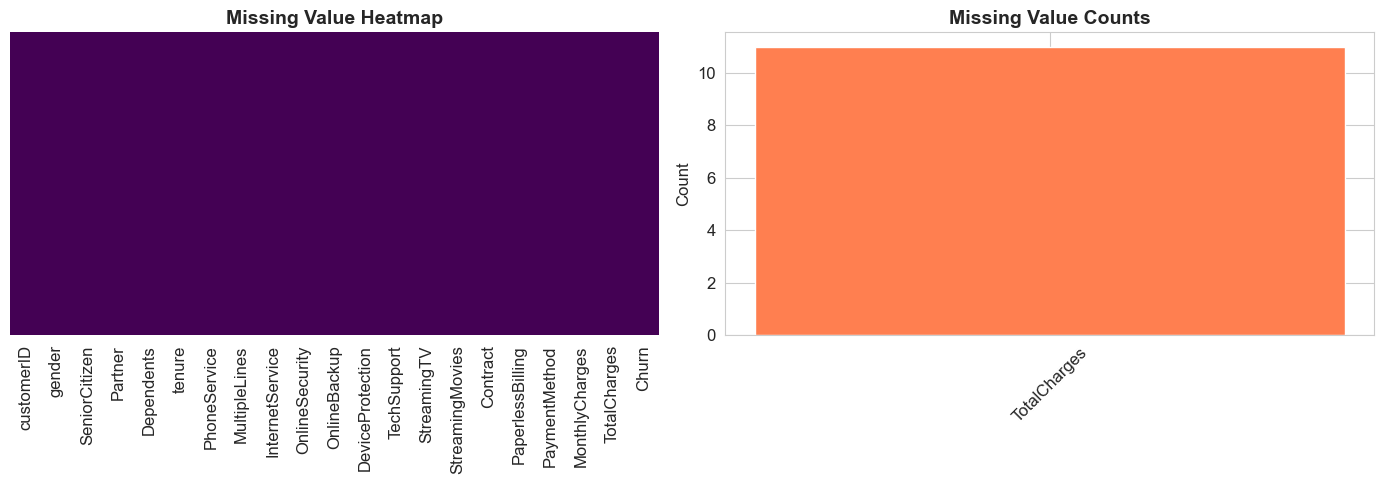

In [8]:
# TotalCharges is a string in the raw CSV — spaces become NaN after coercion
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing     = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
missing_df  = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct.round(2)})

print('Missing Values:')
display(missing_df[missing_df['Count'] > 0])

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[0])
axes[0].set_title('Missing Value Heatmap', fontsize=14, fontweight='bold')

nz = missing[missing > 0]
if not nz.empty:
    axes[1].bar(nz.index, nz.values, color='coral')
    axes[1].set_title('Missing Value Counts', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'No columns with missing values\n(TotalCharges NaNs handled next)',
                 ha='center', va='center', fontsize=12)
    axes[1].axis('off')
    axes[1].set_title('Missing Value Counts', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔧 Cell 9 — Data Cleaning & Feature Engineering
Drop the ID column, fill missing values, encode the target, encode binary columns, and create new informative features.

In [9]:
# 1. Drop customerID — not useful for modelling
df.drop('customerID', axis=1, inplace=True)

# 2. Fill missing TotalCharges (new customers with tenure=0)
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)

# 3. Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'MultipleLines']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(df[col])

# 5. Encode service columns (Yes=1, No/No internet service/No phone service=0)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].map({'Yes': 1, 'No': 0,
                               'No internet service': 0, 'No phone service': 0})

# 6. Feature Engineering
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-1 yr', '1-2 yrs', '2-4 yrs', '4-5 yrs', '5+ yrs']
)

df['ChargeGroup'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 30, 60, 90, 120],
    labels=['Low', 'Medium', 'High', 'Very High']
)

all_service_cols = ['PhoneService'] + service_cols
df['NumServices'] = df[all_service_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1)

df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

print('✅ Cleaning & feature engineering complete.')
print(f'Dataset shape: {df.shape}')
display(df.head())


✅ Cleaning & feature engineering complete.
Dataset shape: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ChargeGroup,NumServices,AvgMonthlySpend
0,Female,0,1,0,1,0,No phone service,DSL,0,1,...,Month-to-month,1,Electronic check,29.85,29.85,0,0-1 yr,Low,1,14.925000
1,Male,0,0,0,34,1,0.0,DSL,1,0,...,One year,0,Mailed check,56.95,1889.50,0,2-4 yrs,Medium,3,53.985714
2,Male,0,0,0,2,1,0.0,DSL,1,1,...,Month-to-month,1,Mailed check,53.85,108.15,1,0-1 yr,Medium,3,36.050000
3,Male,0,0,0,45,0,No phone service,DSL,1,0,...,One year,0,Bank transfer (automatic),42.30,1840.75,0,2-4 yrs,Medium,3,40.016304
4,Female,0,0,0,2,1,0.0,Fiber optic,0,0,...,Month-to-month,1,Electronic check,70.70,151.65,1,0-1 yr,High,1,50.550000


## 🥧 Cell 10 — Churn Distribution Chart
Visualise the overall balance between churned and retained customers.

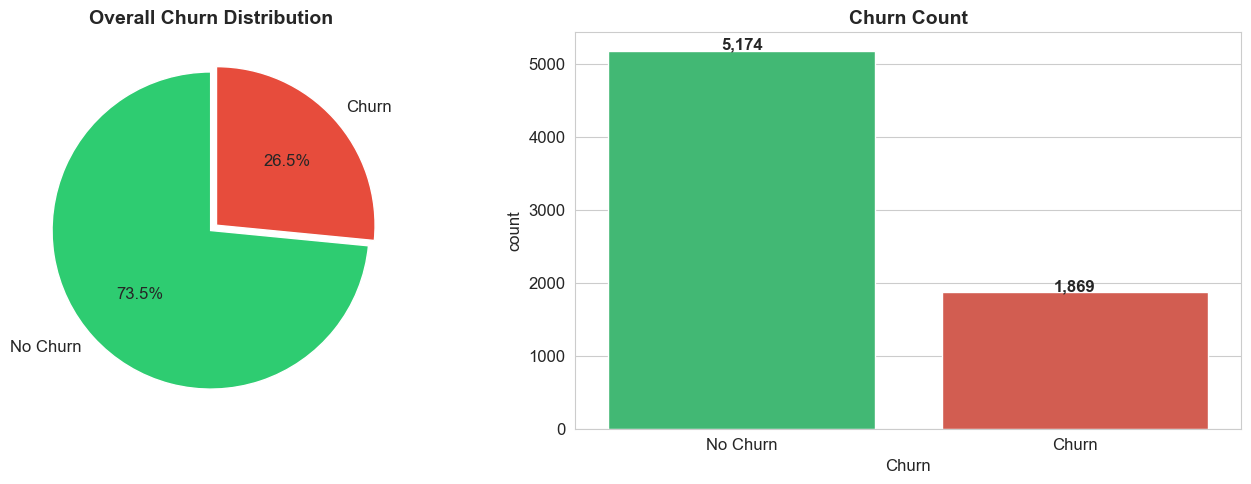

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']
churn_counts = df['Churn'].value_counts()

axes[0].pie(
    churn_counts, labels=['No Churn', 'Churn'],
    autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.05)
)
axes[0].set_title('Overall Churn Distribution', fontsize=14, fontweight='bold')

sns.countplot(data=df, x='Churn', palette=colors, ax=axes[1])
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No Churn', 'Churn'])
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 20),
                     ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 👥 Cell 11 — Churn Rate by Demographics
Churn rates split by gender, senior status, partner, dependents, tenure group, and charge group.

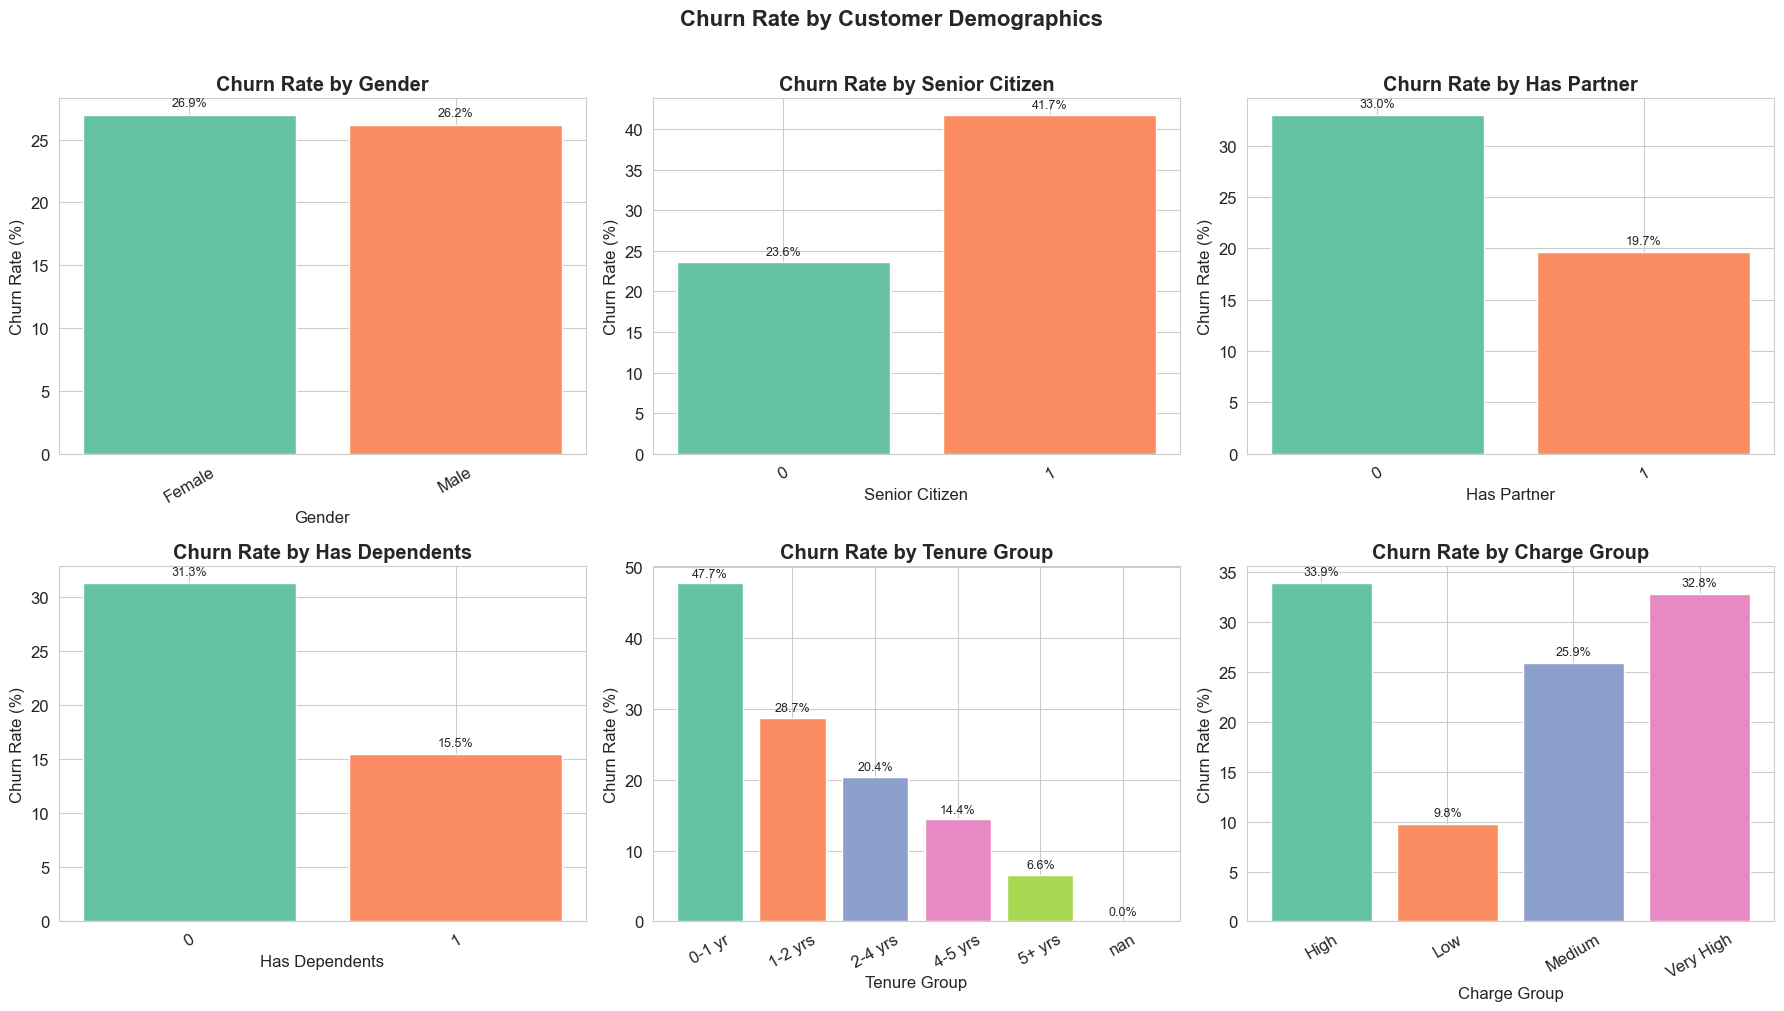

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'TenureGroup', 'ChargeGroup']
labels_map = {
    'gender': 'Gender', 'SeniorCitizen': 'Senior Citizen',
    'Partner': 'Has Partner', 'Dependents': 'Has Dependents',
    'TenureGroup': 'Tenure Group', 'ChargeGroup': 'Charge Group'
}

for ax, col in zip(axes.flatten(), demo_cols):
    temp = df.copy()
    temp[col] = temp[col].astype(str)
    churn_rate = temp.groupby(col)['Churn'].mean() * 100
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=sns.color_palette('Set2', len(churn_rate)))
    ax.set_title(f'Churn Rate by {labels_map.get(col, col)}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel(labels_map.get(col, col))
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Churn Rate by Customer Demographics', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('churn_demographics.png', dpi=150, bbox_inches='tight')
plt.show()


## 📋 Cell 12 — Churn by Contract & Payment Method
Two of the strongest churn predictors — contract type and payment method.

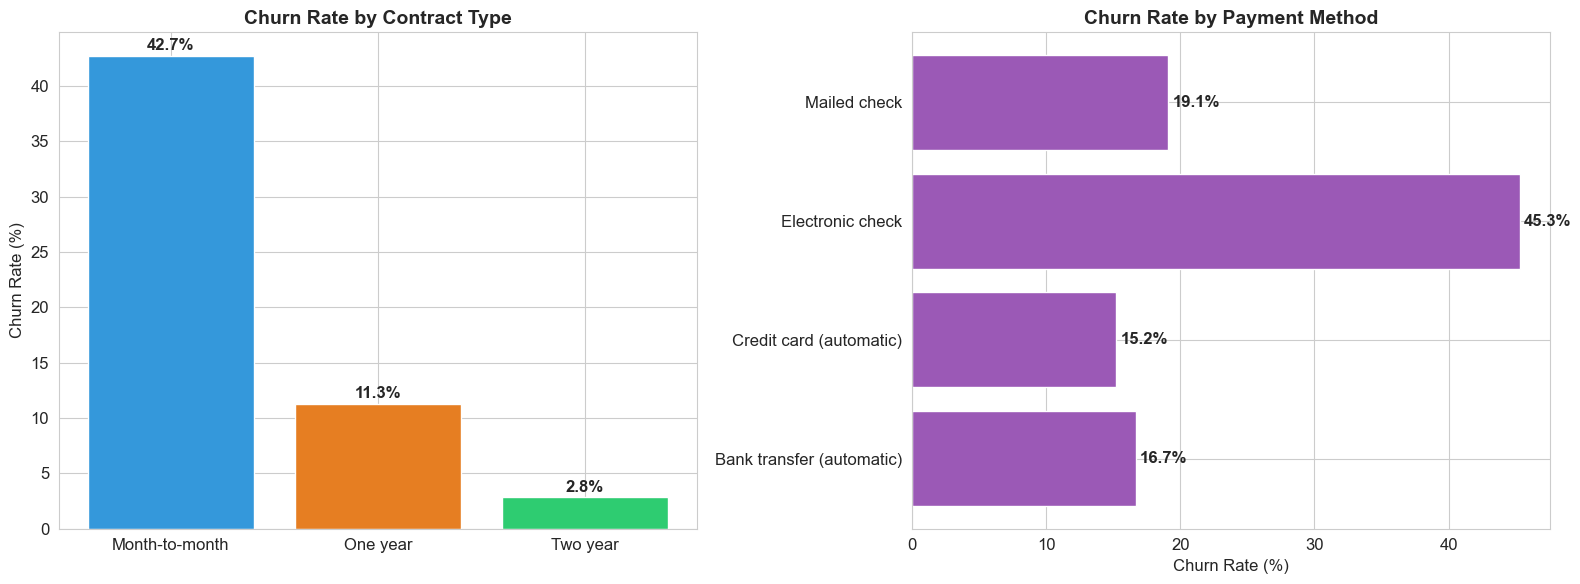

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

contract_churn = df.groupby('Contract')['Churn'].mean() * 100
axes[0].bar(contract_churn.index, contract_churn.values,
            color=['#3498db', '#e67e22', '#2ecc71'])
axes[0].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

payment_churn = df.groupby('PaymentMethod')['Churn'].mean() * 100
axes[1].barh(payment_churn.index, payment_churn.values, color='#9b59b6')
axes[1].set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')
for i, v in enumerate(payment_churn.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_contract_payment.png', dpi=150, bbox_inches='tight')
plt.show()


## 📈 Cell 13 — Numeric Feature Distributions by Churn
Overlapping histograms for `tenure`, `MonthlyCharges`, and `TotalCharges` — churned vs. retained.

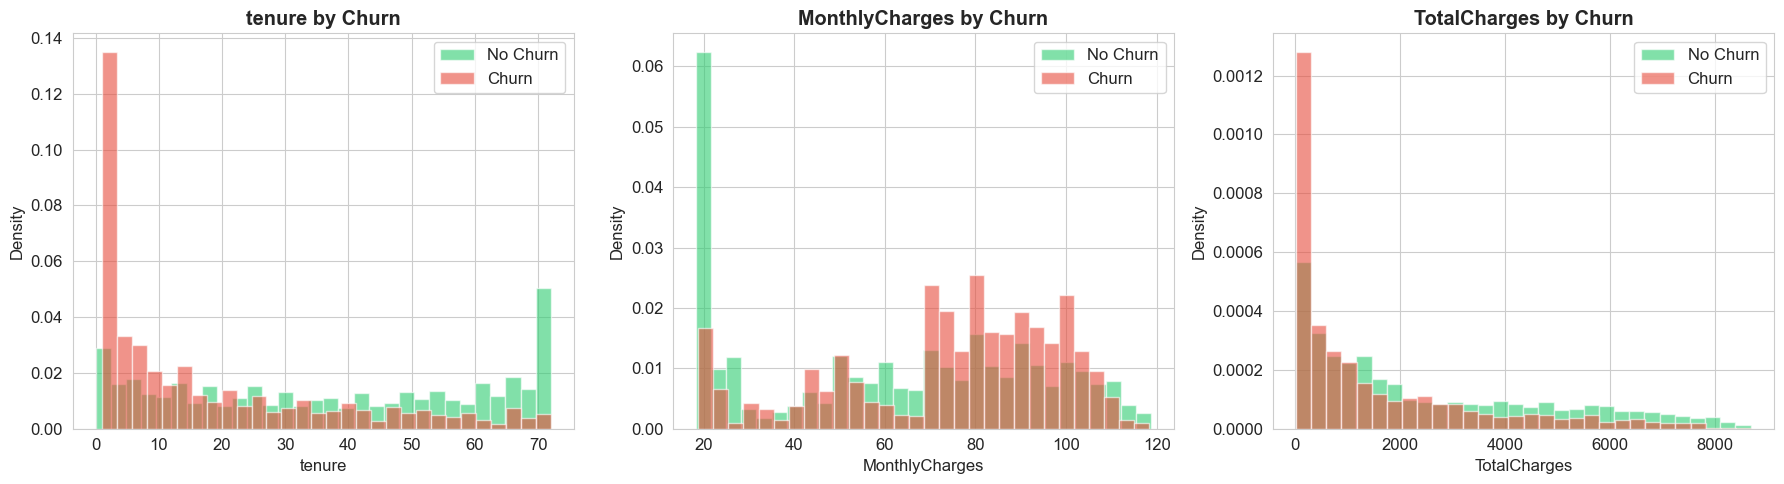

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for ax, col in zip(axes, num_cols):
    df[df['Churn'] == 0][col].hist(bins=30, ax=ax, alpha=0.6,
                                   color='#2ecc71', label='No Churn', density=True)
    df[df['Churn'] == 1][col].hist(bins=30, ax=ax, alpha=0.6,
                                   color='#e74c3c', label='Churn', density=True)
    ax.set_title(f'{col} by Churn', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 🌡️ Cell 14 — Correlation Heatmap
Correlation matrix for all numeric features including the target `Churn`.

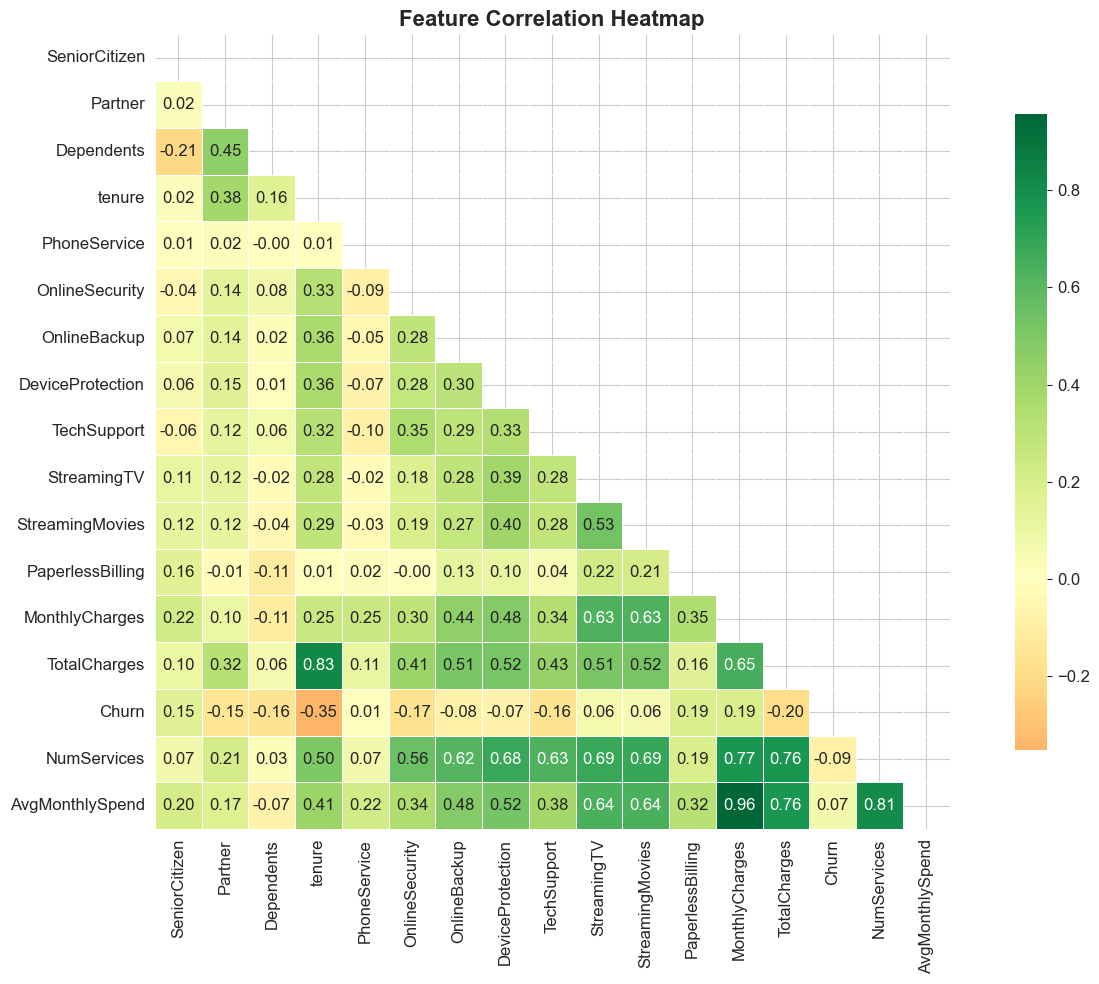

In [14]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 🌐 Cell 15 — Internet Services Heatmap
Churn rate (%) for customers with vs. without each internet add-on service.

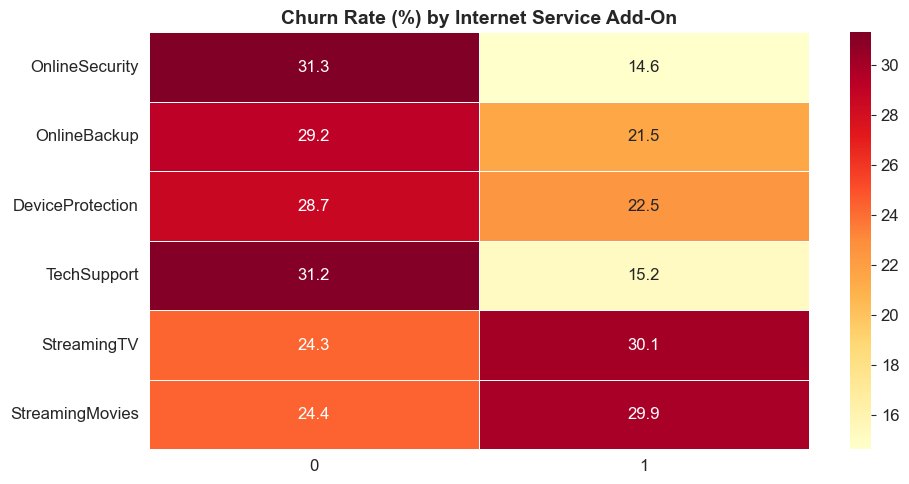

In [15]:
internet_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                     'TechSupport', 'StreamingTV', 'StreamingMovies']

service_churn = {}
for col in internet_services:
    if col in df.columns:
        s = df.groupby(col)['Churn'].mean() * 100
        service_churn[col] = s

service_df = pd.DataFrame(service_churn).T.fillna(0)

plt.figure(figsize=(10, 5))
sns.heatmap(service_df, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Churn Rate (%) by Internet Service Add-On', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('services_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔢 Cell 16 — Churn by Number of Services
Customers subscribed to fewer services tend to churn more.

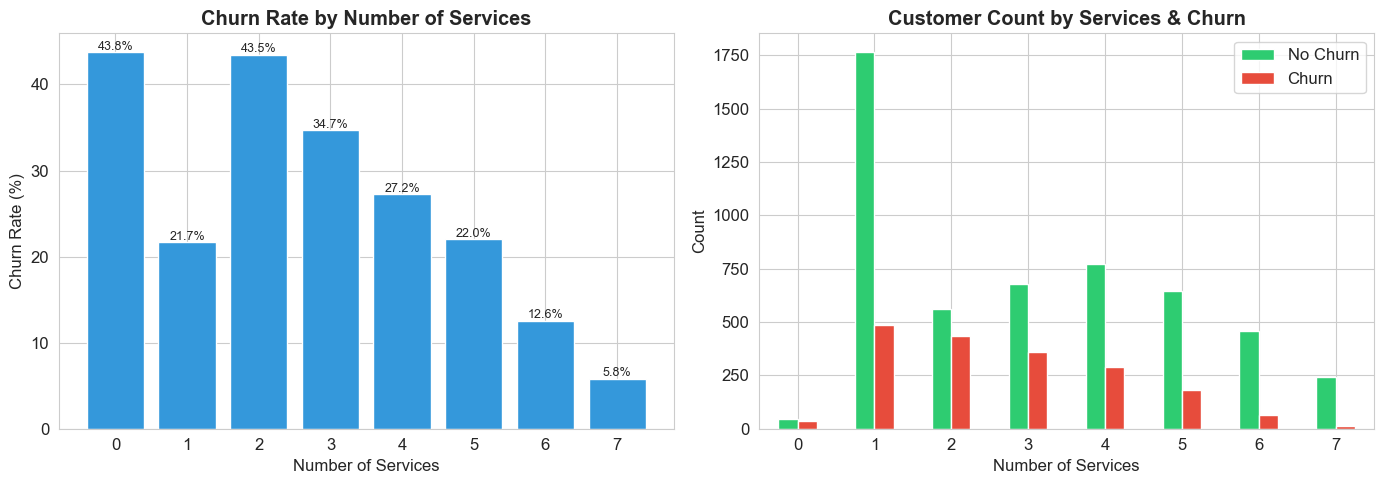

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

svc_churn = df.groupby('NumServices')['Churn'].mean() * 100
axes[0].bar(svc_churn.index, svc_churn.values, color='#3498db')
axes[0].set_title('Churn Rate by Number of Services', fontweight='bold')
axes[0].set_xlabel('Number of Services')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in zip(svc_churn.index, svc_churn.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

df.groupby(['NumServices', 'Churn']).size().unstack().plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='white'
)
axes[1].set_title('Customer Count by Services & Churn', fontweight='bold')
axes[1].set_xlabel('Number of Services')
axes[1].set_ylabel('Count')
axes[1].legend(['No Churn', 'Churn'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('services_churn.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔵 Cell 17 — K-Means: Elbow Method
Find the optimal number of customer clusters using the within-cluster sum of squares (inertia).

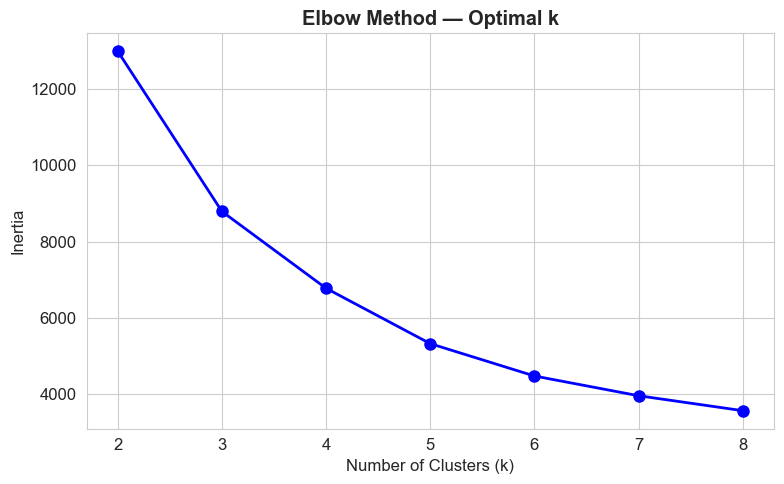

Look for the elbow point where inertia stops dropping sharply.


In [17]:
seg_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']
seg_df = df[seg_features].copy()

scaler_seg = StandardScaler()
seg_scaled = scaler_seg.fit_transform(seg_df)

inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(seg_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k', fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Look for the elbow point where inertia stops dropping sharply.')


## 🗺️ Cell 18 — K-Means Clustering (k=4) + PCA Visualisation
Fit 4 customer segments and project them onto 2D with PCA.

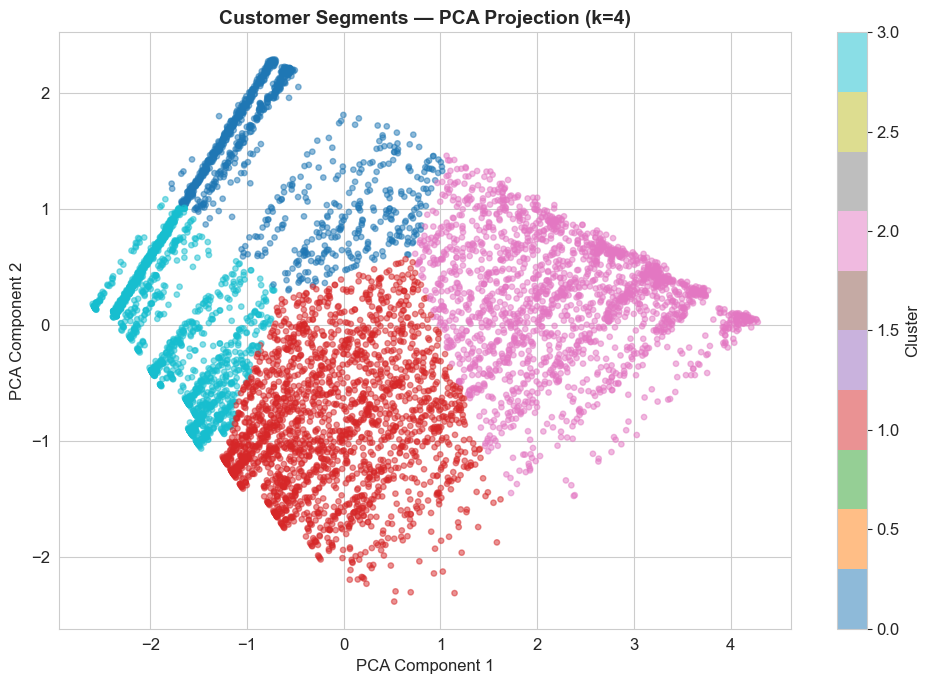

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(seg_scaled)

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(seg_scaled)
df['PCA1'] = pca_coords[:, 0]
df['PCA2'] = pca_coords[:, 1]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'],
                      cmap='tab10', alpha=0.5, s=15)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments — PCA Projection (k=4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()


## 📋 Cell 19 — Cluster Profile Analysis
Average characteristics and churn rate per segment, plus a bar chart of churn by cluster.

Customer Segment Profiles:


,Avg Tenure,Avg Monthly Charges,Avg Total Charges,Avg Services,Churn Rate (%)
Cluster,,,,,
0,53.614,30.959,1646.625,1.480,4.6
1,18.375,80.409,1452.591,3.284,43.0
2,59.830,92.087,5500.739,5.057,14.5
3,8.959,37.706,295.584,1.203,32.0


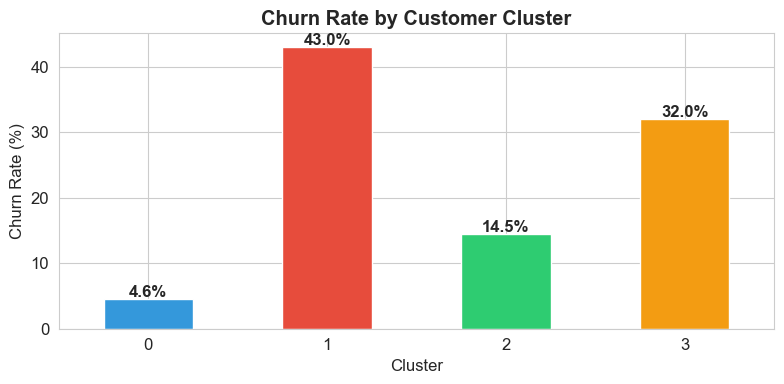

In [19]:
cluster_profile = df.groupby('Cluster')[seg_features + ['Churn']].mean().round(3)
cluster_profile.columns = ['Avg Tenure', 'Avg Monthly Charges',
                            'Avg Total Charges', 'Avg Services', 'Churn Rate']
cluster_profile['Churn Rate (%)'] = (cluster_profile['Churn Rate'] * 100).round(1)
cluster_profile.drop('Churn Rate', axis=1, inplace=True)

print('Customer Segment Profiles:')
display(cluster_profile)

plt.figure(figsize=(8, 4))
cluster_profile['Churn Rate (%)'].plot(
    kind='bar', color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
)
plt.title('Churn Rate by Customer Cluster', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(cluster_profile['Churn Rate (%)']):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()


## ⚙️ Cell 20 — Encode Remaining Categorical Features
Label-encode any remaining object-dtype columns before modelling.

In [20]:
# Drop display-only columns not needed for the model
df_model = df.drop(
    columns=['TenureGroup', 'ChargeGroup', 'PCA1', 'PCA2', 'Cluster'],
    errors='ignore'
)

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'Encoding columns: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print('✅ Label encoding complete.')
print(f'Model-ready dataset: {df_model.shape[0]:,} rows × {df_model.shape[1]} columns')
display(df_model.head())


Encoding columns: ['gender', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']
✅ Label encoding complete.
Model-ready dataset: 7,043 rows × 22 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NumServices,AvgMonthlySpend
0,0,0,1,0,1,0,2,0,0,1,...,0,0,0,1,2,29.85,29.85,0,1,14.925000
1,1,0,0,0,34,1,0,0,1,0,...,0,0,1,0,3,56.95,1889.50,0,3,53.985714
2,1,0,0,0,2,1,0,0,1,1,...,0,0,0,1,3,53.85,108.15,1,3,36.050000
3,1,0,0,0,45,0,2,0,1,0,...,0,0,1,0,0,42.30,1840.75,0,3,40.016304
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,1,1,50.550000


## ✂️ Cell 21 — Train / Test Split, Standardisation & SMOTE
Split 80/20 with stratification, standardise numeric features, then apply SMOTE to balance the training set.

In [21]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print(f'Features: {X.shape[1]}   |   Samples: {X.shape[0]:,}')
print(f'Class distribution:\n{y.value_counts()}')

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

# Standardise
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE — oversample minority class in training set only
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print(f'\nAfter SMOTE — training class distribution:')
print(pd.Series(y_train_sm).value_counts().rename({0: 'No Churn', 1: 'Churn'}))
print('✅ Data ready for modelling.')


Features: 21   |   Samples: 7,043
Class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Train: 5,634  |  Test: 1,409

After SMOTE — training class distribution:
Churn
No Churn    4139
Churn       4139
Name: count, dtype: int64
✅ Data ready for modelling.


## 🤖 Cell 22 — Train All 5 Machine Learning Models
Train: Logistic Regression, Random Forest, Gradient Boosting, AdaBoost, and K-Nearest Neighbours.

In [22]:
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost'             : AdaBoostClassifier(n_estimators=200, random_state=42),
    'K-Nearest Neighbours' : KNeighborsClassifier(n_neighbors=7),
}

results = {}
trained_models = {}

print('Training models...')
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model
    print(f'  ✅ {name}')

print('\nAll models trained.')


Training models...
  ✅ Logistic Regression
  ✅ Random Forest
  ✅ Gradient Boosting
  ✅ AdaBoost
  ✅ K-Nearest Neighbours

All models trained.


## 📏 Cell 23 — Evaluate All Models on the Test Set
Compute Accuracy, Precision, Recall, F1, and ROC-AUC for every model.

In [23]:
feature_names = X.columns.tolist()

print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print('-' * 75)

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_prob) if y_prob is not None else 0.0

    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1': f1, 'ROC-AUC': roc, 'y_pred': y_pred, 'y_prob': y_prob
    }
    print(f'{name:<22} {acc:>10.3f} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f} {roc:>10.3f}')


Model                    Accuracy  Precision     Recall         F1    ROC-AUC
---------------------------------------------------------------------------
Logistic Regression         0.748      0.517      0.789      0.624      0.846
Random Forest               0.769      0.562      0.586      0.573      0.824
Gradient Boosting           0.781      0.577      0.652      0.612      0.837
AdaBoost                    0.764      0.541      0.730      0.621      0.839
K-Nearest Neighbours        0.683      0.441      0.735      0.552      0.763


## 🔁 Cell 24 — 5-Fold Stratified Cross-Validation
Validate model stability: mean and std of F1 score across 5 folds.

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':<22}  {'CV F1 Mean':>12}  {'± Std':>8}")
print('-' * 48)
for name, model in trained_models.items():
    scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='f1')
    print(f'{name:<22}  {scores.mean():>12.3f}  {scores.std():>8.3f}')


Model                     CV F1 Mean     ± Std
------------------------------------------------
Logistic Regression            0.782     0.006
Random Forest                  0.858     0.006
Gradient Boosting              0.853     0.010
AdaBoost                       0.834     0.009
K-Nearest Neighbours           0.808     0.006


## 📊 Cell 25 — Model Performance Bar Chart
Side-by-side comparison of all 5 metrics across all 5 models.

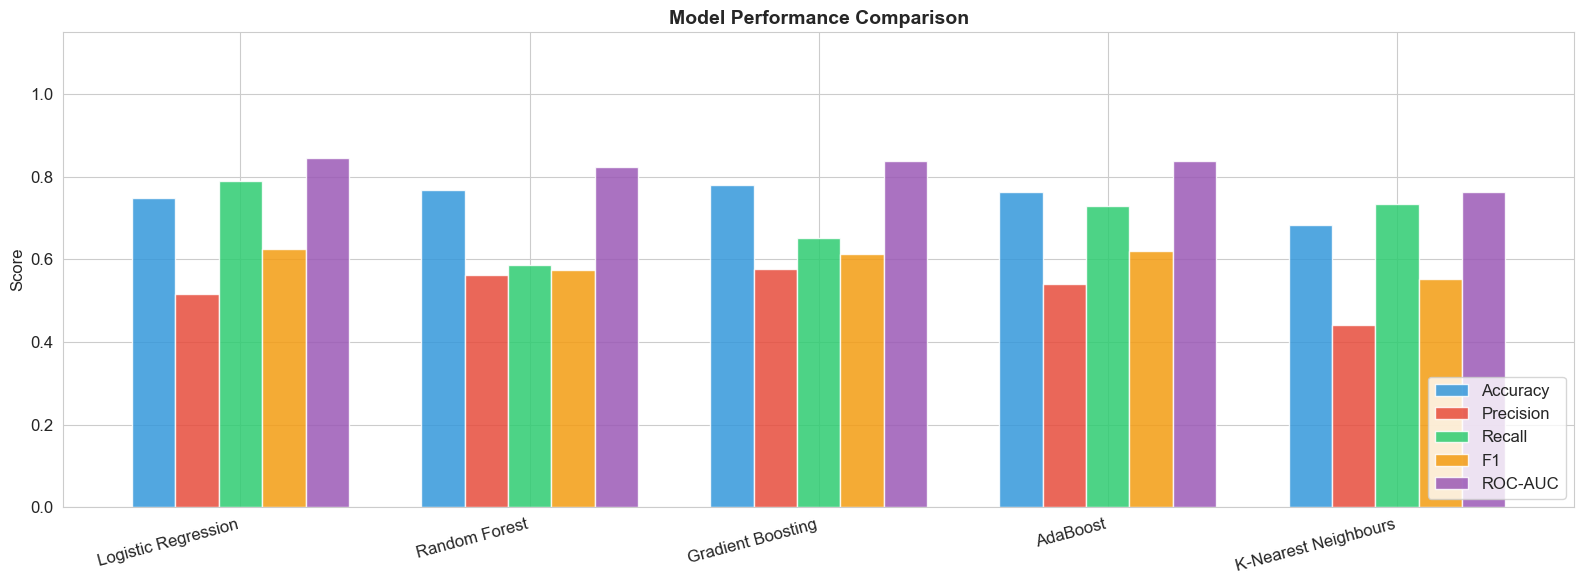

In [25]:
results_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k not in ['y_pred', 'y_prob']}
    for name, vals in results.items()
}).T

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(results_df.index))
width = 0.15
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width,
           label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 📉 Cell 26 — ROC Curves
ROC curves with AUC scores for all 5 models — higher and further left is better.

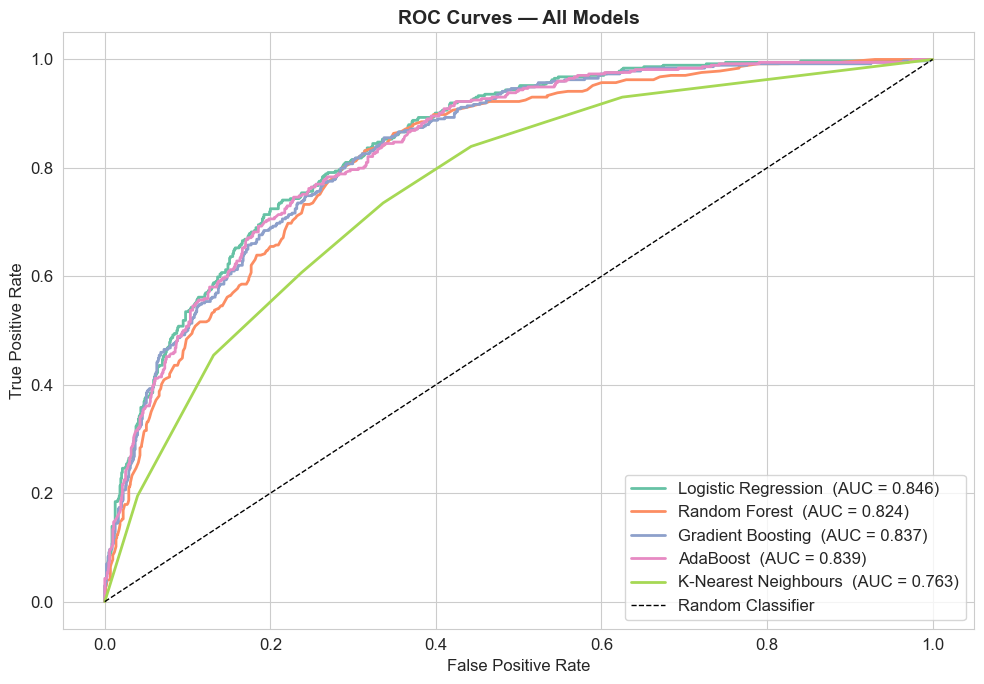

In [26]:
plt.figure(figsize=(10, 7))
for name, vals in results.items():
    if vals['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, vals['y_prob'])
        plt.plot(fpr, tpr, lw=2, label=f"{name}  (AUC = {vals['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔲 Cell 27 — Confusion Matrices (All 5 Models)
True/False Positive and Negative counts for every model side by side.

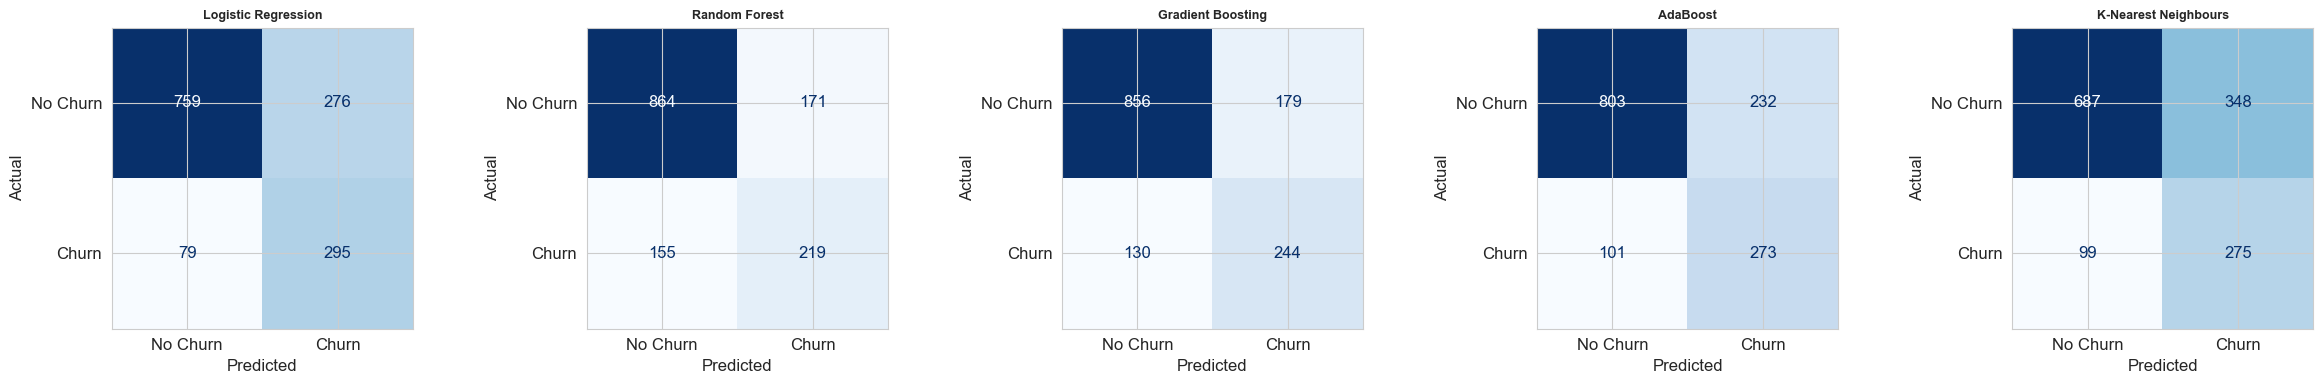

In [27]:
fig, axes = plt.subplots(1, 5, figsize=(24, 4))
for ax, (name, vals) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, vals['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 🏆 Cell 28 — Best Model & Feature Importance
Identify the best model by ROC-AUC and plot its top 20 most important features.

🏆 Best Model : Logistic Regression
   ROC-AUC   = 0.8457
   F1 Score  = 0.6243
   Recall    = 0.7888


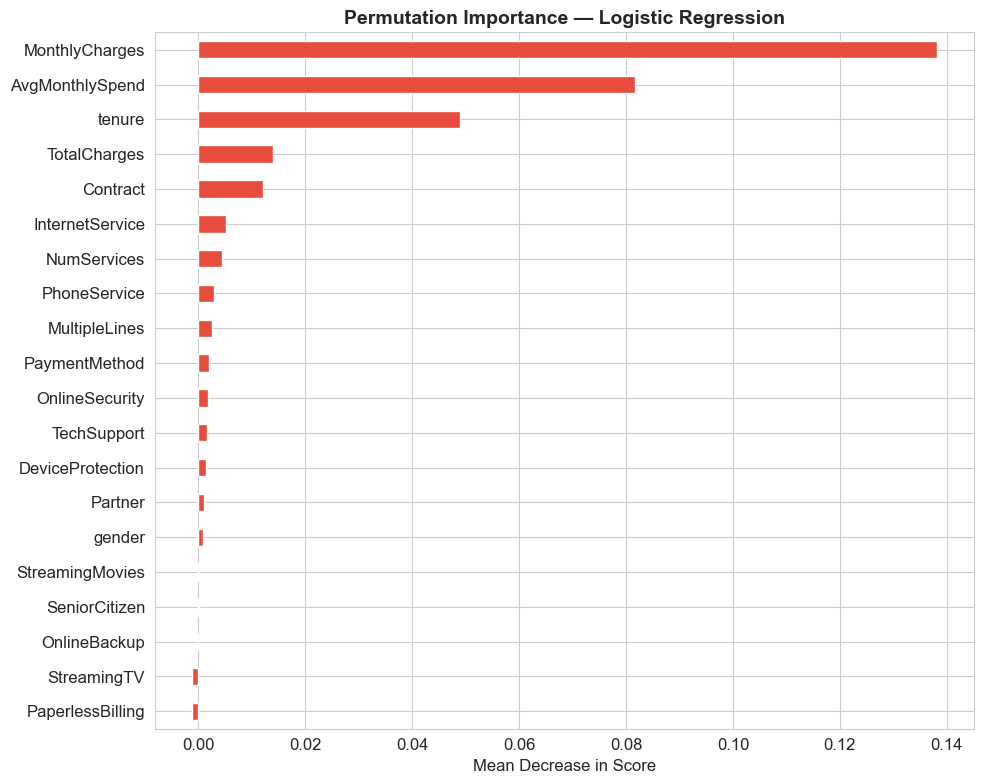

In [28]:
best_name  = max(results, key=lambda k: results[k]['ROC-AUC'])
best_model = trained_models[best_name]

print(f'🏆 Best Model : {best_name}')
print(f'   ROC-AUC   = {results[best_name]["ROC-AUC"]:.4f}')
print(f'   F1 Score  = {results[best_name]["F1"]:.4f}')
print(f'   Recall    = {results[best_name]["Recall"]:.4f}')

if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_,
                         index=feature_names).sort_values(ascending=True)
    plt.figure(figsize=(10, 8))
    feat_imp.tail(20).plot(kind='barh', color='#3498db')
    plt.title(f'Top 20 Feature Importances — {best_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    perm = permutation_importance(best_model, X_test_scaled, y_test,
                                  n_repeats=10, random_state=42)
    perm_imp = pd.Series(perm.importances_mean,
                         index=feature_names).sort_values(ascending=True)
    plt.figure(figsize=(10, 8))
    perm_imp.tail(20).plot(kind='barh', color='#e74c3c')
    plt.title(f'Permutation Importance — {best_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Mean Decrease in Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()


## 🔍 Cell 29 — XAI: LIME Local Explanation
LIME explains **why the model predicted churn for one specific customer** — showing which feature values pushed the probability up or down.

LIME Explanation — Test Customer #9
Predicted churn probability: 0.499

Feature                                    Weight  Direction
-----------------------------------------------------------------
MonthlyCharges <= -0.65                   -0.4783  ↓ Away from Churn
-1.08 < tenure <= -0.45                   +0.1062  ↑ Towards Churn
-0.80 < AvgMonthlySpend <= 0.13           +0.0845  ↑ Towards Churn
Contract <= -0.83                         +0.0731  ↑ Towards Churn
-0.88 < TotalCharges <= -0.50             -0.0595  ↓ Away from Churn
TechSupport <= -0.64                      +0.0384  ↑ Towards Churn
NumServices <= -1.06                      +0.0281  ↑ Towards Churn
OnlineSecurity <= -0.64                   +0.0268  ↑ Towards Churn
-1.20 < PaperlessBilling <= 0.83          +0.0233  ↑ Towards Churn
Dependents <= -0.65                       +0.0233  ↑ Towards Churn


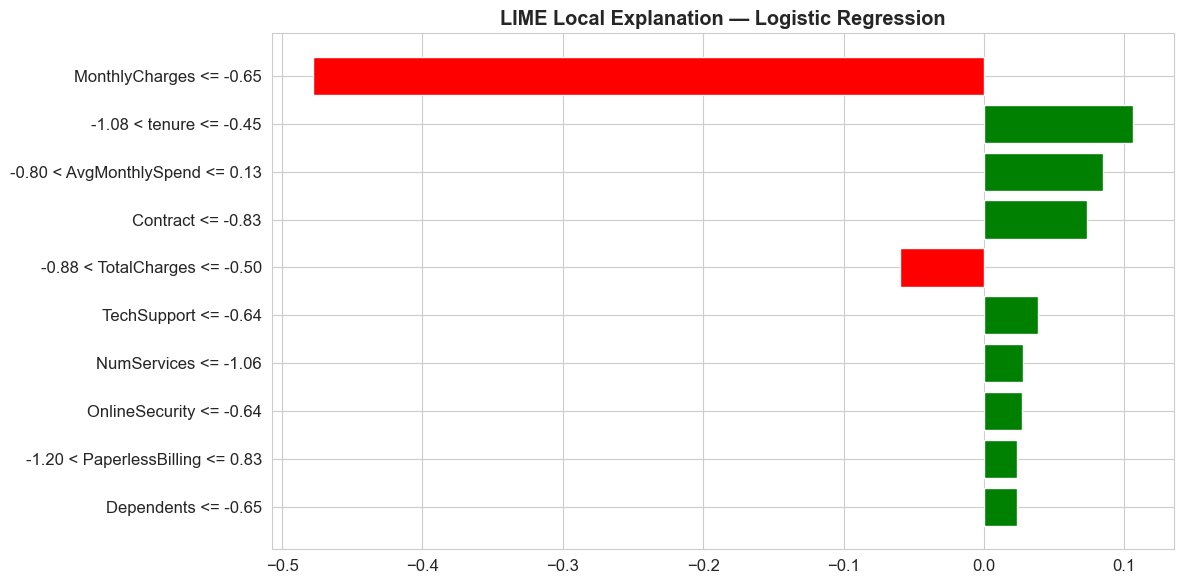

In [29]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_sm,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    mode='classification',
    random_state=42
)

# Pick the first correctly-predicted churner from the test set
churn_idx = np.where(y_test.values == 1)[0][0]
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_scaled[churn_idx],
    predict_fn=best_model.predict_proba,
    num_features=10
)

prob = best_model.predict_proba(X_test_scaled[churn_idx:churn_idx+1])[0][1]
print(f'LIME Explanation — Test Customer #{churn_idx}')
print(f'Predicted churn probability: {prob:.3f}\n')
print(f"{'Feature':<40} {'Weight':>8}  Direction")
print('-' * 65)
for feat, weight in lime_exp.as_list():
    direction = '↑ Towards Churn' if weight > 0 else '↓ Away from Churn'
    print(f'{feat:<40} {weight:>+8.4f}  {direction}')

fig = lime_exp.as_pyplot_figure()
plt.title(f'LIME Local Explanation — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('lime_explanation.png', dpi=150, bbox_inches='tight')
plt.show()


## 🌍 Cell 30 — XAI: SHAP Global Feature Importance (Bar)
SHAP bar chart shows the **average absolute impact** of each feature across all test predictions.

  0%|          | 0/100 [00:00<?, ?it/s]

sv shape     : (100, 21)
X_shap shape : (100, 21)


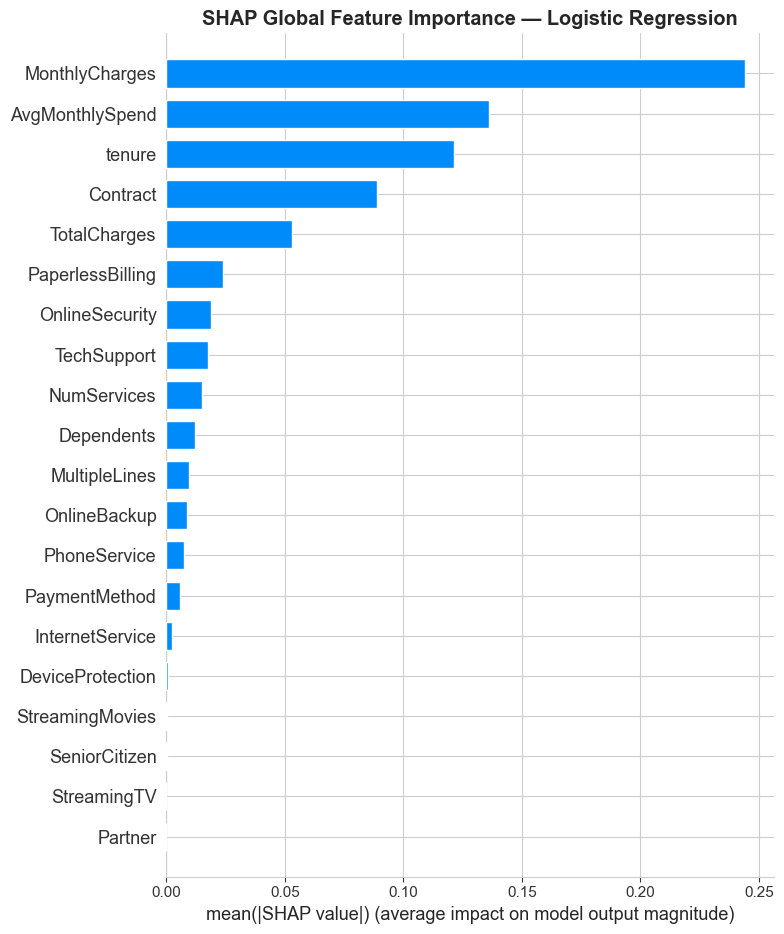

✅ SHAP bar chart saved.


In [30]:
if hasattr(best_model, 'feature_importances_'):
    shap_explainer = shap.TreeExplainer(best_model)
    shap_values_raw = shap_explainer.shap_values(X_test_scaled)

    # Handle all possible output shapes from TreeExplainer
    if isinstance(shap_values_raw, list):
        # Old SHAP: list of arrays, one per class → take class 1 (Churn)
        sv = shap_values_raw[1]
    elif shap_values_raw.ndim == 3:
        # New SHAP: 3D array (n_samples, n_features, n_classes) → take class 1
        sv = shap_values_raw[:, :, 1]
    else:
        # Single output (e.g. GradientBoosting)
        sv = shap_values_raw

    X_shap = X_test_scaled

else:
    sample_idx     = np.random.choice(len(X_train_sm), 100, replace=False)
    shap_explainer = shap.KernelExplainer(best_model.predict_proba, X_train_sm[sample_idx])
    shap_values_raw = shap_explainer.shap_values(X_test_scaled[:100])
    sv = shap_values_raw[1] if isinstance(shap_values_raw, list) else shap_values_raw[:, :, 1]
    X_shap = X_test_scaled[:100]

# Confirm shapes match before plotting
print(f"sv shape     : {sv.shape}")
print(f"X_shap shape : {X_shap.shape}")
assert sv.shape == X_shap.shape, "Shape mismatch — check SHAP extraction above"

plt.figure()
shap.summary_plot(sv, X_shap, feature_names=feature_names, plot_type='bar', show=False)
plt.title(f'SHAP Global Feature Importance — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP bar chart saved.')

## 🐝 Cell 31 — XAI: SHAP Beeswarm Plot
The beeswarm shows **both direction and magnitude** — red = high feature value, blue = low. Points to the right push towards churn.

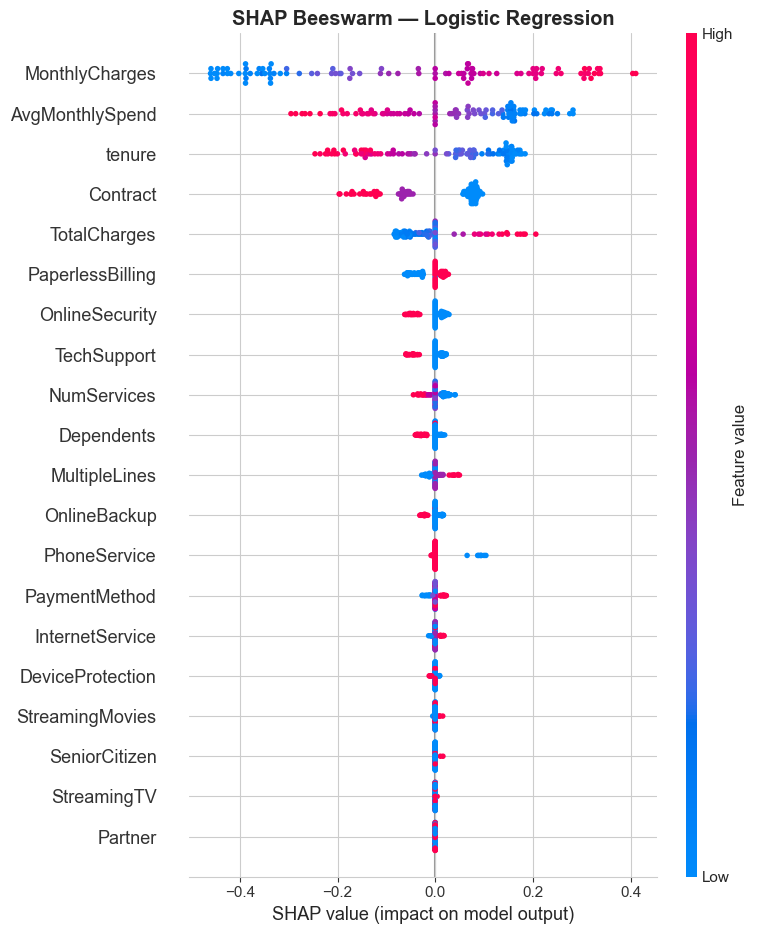

✅ SHAP beeswarm chart saved.


In [31]:
plt.figure()
shap.summary_plot(sv, X_shap, feature_names=feature_names, show=False)
plt.title(f'SHAP Beeswarm — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP beeswarm chart saved.')

## 🎯 Cell 32 — Generate Churn Probability Scores
Score every customer and classify them as Low / Medium / High risk.

In [32]:
all_scaled  = scaler.transform(X)
churn_probs = best_model.predict_proba(all_scaled)[:, 1]

df_output = X.copy()
df_output['ChurnProbability'] = churn_probs
df_output['Actual_Churn']     = y.values
df_output['RiskCategory']     = pd.cut(
    churn_probs,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print('Risk Category Distribution:')
print(df_output['RiskCategory'].value_counts())
display(df_output[['ChurnProbability', 'RiskCategory', 'Actual_Churn']].head(10))


Risk Category Distribution:
RiskCategory
Low Risk       3101
High Risk      2271
Medium Risk    1671
Name: count, dtype: int64


,ChurnProbability,RiskCategory,Actual_Churn
0,0.819372,High Risk,0
1,0.103887,Low Risk,0
2,0.603872,High Risk,1
3,0.072688,Low Risk,0
4,0.870711,High Risk,1
5,0.890024,High Risk,1
6,0.686684,High Risk,0
7,0.505148,Medium Risk,0
8,0.765732,High Risk,1
9,0.025250,Low Risk,0


## 📊 Cell 33 — Churn Risk Distribution Charts
Histogram of predicted probabilities and pie chart of risk tier proportions.

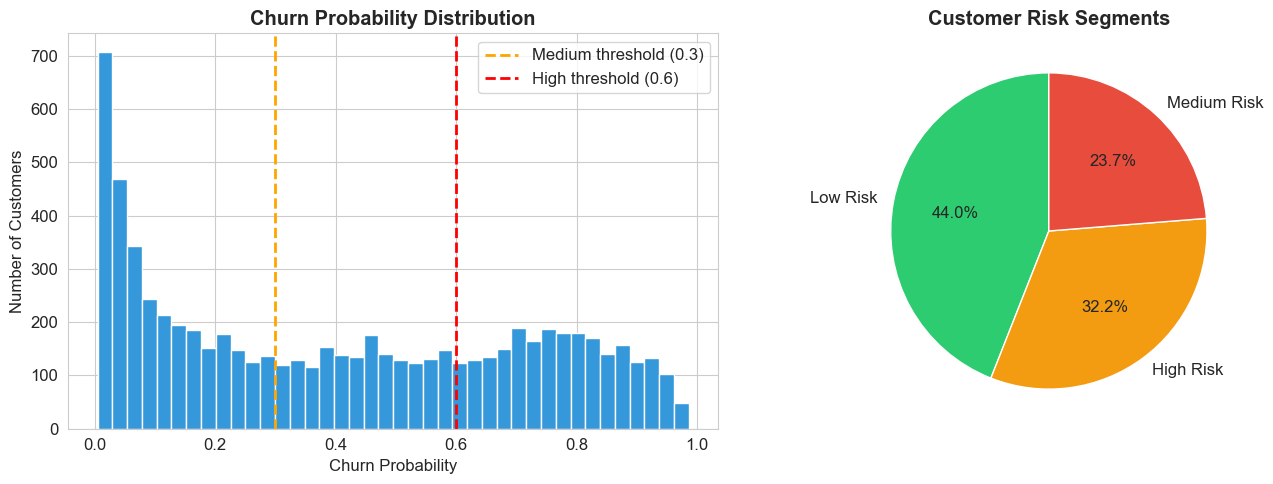

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_output['ChurnProbability'], bins=40, color='#3498db', edgecolor='white')
axes[0].axvline(0.3, color='orange', linestyle='--', linewidth=2, label='Medium threshold (0.3)')
axes[0].axvline(0.6, color='red',    linestyle='--', linewidth=2, label='High threshold (0.6)')
axes[0].set_xlabel('Churn Probability')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Churn Probability Distribution', fontweight='bold')
axes[0].legend()

risk_counts = df_output['RiskCategory'].value_counts()
axes[1].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90)
axes[1].set_title('Customer Risk Segments', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 💾 Cell 34 — Export Scored Customer List to CSV
Save every customer's churn probability and risk tier for use by the retention team.

In [34]:
df_output.to_csv('customers_with_churn_scores.csv', index=False)
print(f'✅ Saved: customers_with_churn_scores.csv')
print(f'   {df_output.shape[0]:,} customers  ×  {df_output.shape[1]} columns')
print('\nSummary statistics:')
display(df_output[['ChurnProbability', 'Actual_Churn']].describe().round(3))


✅ Saved: customers_with_churn_scores.csv
   7,043 customers  ×  24 columns

Summary statistics:


,ChurnProbability,Actual_Churn
count,7043.000,7043.000
mean,0.407,0.265
std,0.306,0.442
min,0.005,0.000
25%,0.103,0.000
50%,0.383,0.000
75%,0.694,1.000
max,0.986,1.000


## 💼 Cell 35 — Business Recommendations
Actionable retention strategies per risk tier, grounded in XAI insights.

In [35]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           BUSINESS RECOMMENDATIONS FOR RETENTION            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  🔴 HIGH RISK  (> 60% churn probability)                    ║
║     → Immediate personal outreach (call / dedicated email)  ║
║     → Offer loyalty discounts or contract upgrade deals     ║
║     → Priority tech support & proactive service review      ║
║     → Targeted retention packages (e.g., free months)       ║
║                                                              ║
║  🟡 MEDIUM RISK  (30–60% churn probability)                 ║
║     → Automated engagement (newsletters, personalised tips) ║
║     → Incentivise switch to 1- or 2-year contracts          ║
║     → Proactive satisfaction surveys                        ║
║     → Bundle service upgrade promotions                     ║
║                                                              ║
║  🟢 LOW RISK  (< 30% churn probability)                     ║
║     → Standard service maintenance                          ║
║     → Loyalty reward programmes                             ║
║     → Upsell premium / add-on services                      ║
║     → Referral incentive campaigns                          ║
║                                                              ║
║  KEY CHURN DRIVERS (from XAI analysis):                     ║
║     1. Month-to-month contract   (highest churn risk)       ║
║     2. High monthly charges                                 ║
║     3. Low tenure  (new customers most vulnerable)          ║
║     4. No online security / tech support                    ║
║     5. Electronic check payment method                      ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║           BUSINESS RECOMMENDATIONS FOR RETENTION            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  🔴 HIGH RISK  (> 60% churn probability)                    ║
║     → Immediate personal outreach (call / dedicated email)  ║
║     → Offer loyalty discounts or contract upgrade deals     ║
║     → Priority tech support & proactive service review      ║
║     → Targeted retention packages (e.g., free months)       ║
║                                                              ║
║  🟡 MEDIUM RISK  (30–60% churn probability)                 ║
║     → Automated engagement (newsletters, personalised tips) ║
║     → Incentivise switch to 1- or 2-year contracts          ║
║     → Proactive satisfaction surveys                        ║
║     → Bundle service upgrade promotions                     ║
║                                    

## ✅ Cell 36 — Final Model Performance Summary
Ranked leaderboard of all 5 models, with the winner highlighted.

In [36]:
summary = results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].round(4)
summary = summary.sort_values('ROC-AUC', ascending=False)

print('=' * 65)
print('FINAL MODEL LEADERBOARD  (sorted by ROC-AUC)')
print('=' * 65)
display(summary)

winner = summary.index[0]
print(f'\n🏆  Best Model : {winner}')
print(f'    ROC-AUC   = {summary.loc[winner, "ROC-AUC"]:.4f}')
print(f'    F1 Score  = {summary.loc[winner, "F1"]:.4f}')
print(f'    Recall    = {summary.loc[winner, "Recall"]:.4f}')

print('''
Output files produced:
  missing_values.png          churn_distribution.png
  churn_demographics.png      churn_contract_payment.png
  numeric_distributions.png   correlation_heatmap.png
  services_heatmap.png        services_churn.png
  kmeans_elbow.png            customer_segments.png
  cluster_churn_rates.png     model_comparison.png
  roc_curves.png              confusion_matrices.png
  feature_importance.png      lime_explanation.png
  shap_summary_bar.png        shap_beeswarm.png
  churn_risk_distribution.png customers_with_churn_scores.csv
''')


FINAL MODEL LEADERBOARD  (sorted by ROC-AUC)


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.7480,0.5166,0.7888,0.6243,0.8457
AdaBoost,0.7637,0.5406,0.7299,0.6212,0.8393
Gradient Boosting,0.7807,0.5768,0.6524,0.6123,0.8372
Random Forest,0.7686,0.5615,0.5856,0.5733,0.8242
K-Nearest Neighbours,0.6828,0.4414,0.7353,0.5517,0.7634



🏆  Best Model : Logistic Regression
    ROC-AUC   = 0.8457
    F1 Score  = 0.6243
    Recall    = 0.7888

Output files produced:
  missing_values.png          churn_distribution.png
  churn_demographics.png      churn_contract_payment.png
  numeric_distributions.png   correlation_heatmap.png
  services_heatmap.png        services_churn.png
  kmeans_elbow.png            customer_segments.png
  cluster_churn_rates.png     model_comparison.png
  roc_curves.png              confusion_matrices.png
  feature_importance.png      lime_explanation.png
  shap_summary_bar.png        shap_beeswarm.png
  churn_risk_distribution.png customers_with_churn_scores.csv

